In [44]:
%%capture
%run "EDA.ipynb"


In [45]:
import pickle
from scipy.stats import skew
from scipy.optimize import minimize
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 4.Preprocessing

In [46]:
skew_values = train[numerical_features].apply(lambda x: skew(x.dropna()))
print(skew_values.sort_values(ascending=False))

annual_income           1.719504
debt_to_income_ratio    1.406676
loan_amount             0.207359
interest_rate           0.049945
credit_score           -0.166992
dtype: float64


In [47]:
skewed_cols = skew_values[abs(skew_values) > 1].index.tolist()
print("Highly skewed columns:", skewed_cols)

for col in skewed_cols:
    train[col] = np.log1p(train[col])
    test[col]  = np.log1p(test[col])

from sklearn.preprocessing import PowerTransformer

# Initialize Yeo-Johnson transformer
pt = PowerTransformer(method='yeo-johnson')

# Apply transformation to skewed columns
# train[skewed_cols] = pt.fit_transform(train[skewed_cols])
# test[skewed_cols] = pt.transform(test[skewed_cols])

Highly skewed columns: ['annual_income', 'debt_to_income_ratio']


## Outliers (IQR)

In [48]:
iqr_bounds = {}
for col in numerical_features:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_bounds[col] = (lower_bound, upper_bound)
    
    train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
    test[col] = test[col].clip(lower=lower_bound, upper=upper_bound)

In [49]:
target = 'loan_paid_back'
cols = train.columns.drop(target)

## Target Encoding

In [50]:
def target_encoding(train, predict, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mean_features_train = pd.DataFrame(index=train.index)
    mean_features_test = pd.DataFrame(index=predict.index)

    for col in cols:
        # --- K-Fold Target Mean Encoding ---
        mean_encoded = np.zeros(len(train))
        for tr_idx, val_idx in kf.split(train):
            tr_fold = train.iloc[tr_idx]
            val_fold = train.iloc[val_idx]
            mean_map = tr_fold.groupby(col)[target].mean()
            mean_encoded[val_idx] = val_fold[col].map(mean_map)

        mean_features_train[f'mean_{col}'] = mean_encoded

        # --- Apply global mean mapping to prediction/test data ---
        global_mean = train.groupby(col)[target].mean()
        mean_features_test[f'mean_{col}'] = predict[col].map(global_mean)

    # --- Concatenate new features at once to avoid fragmentation ---
    train = pd.concat([train, mean_features_train], axis=1).copy()
    predict = pd.concat([predict, mean_features_test], axis=1).copy()
    return train, predict

global_target_maps = {col: train.groupby(col)[target].mean().to_dict() for col in cols}
train, test = target_encoding(train, test)

In [51]:
freq_maps = {col: train[col].value_counts().to_dict() for col in cols}
bin_edges_dict = {}
def create_frequency_features(df, df_test):

    # Pre-allocate DataFrames for new features to avoid fragmentation
    freq_features_train = pd.DataFrame(index=df.index)
    freq_features_test = pd.DataFrame(index=df_test.index)
    bin_features_train = pd.DataFrame(index=df.index)
    bin_features_test = pd.DataFrame(index=df_test.index)

    for col in cols:
        # --- Frequency encoding ---
        freq = df[col].value_counts()
        freq_features_train[f"{col}_freq"] = df[col].map(freq)
        freq_features_test[f"{col}_freq"] = df_test[col].map(freq).fillna(freq.mean())

        # --- Quantile binning for numeric columns ---
        if col in numerical_features:
            bin_edges_dict[col] = {}
            for q in [5, 10, 15]:
                try:
                    train_bins, bins = pd.qcut(df[col], q=q, labels=False, retbins=True, duplicates="drop")
                    bin_features_train[f"{col}_bin{q}"] = train_bins
                    bin_features_test[f"{col}_bin{q}"] = pd.cut(df_test[col], bins=bins, labels=False, include_lowest=True)
                    bin_edges_dict[col][q] = bins
                except Exception:
                    bin_features_train[f"{col}_bin{q}"] = 0
                    bin_features_test[f"{col}_bin{q}"] = 0
                    bin_edges_dict[col][q] = None

    # Concatenate all new features at once
    df = pd.concat([df, freq_features_train, bin_features_train], axis=1)
    df_test = pd.concat([df_test, freq_features_test, bin_features_test], axis=1)
    return df, df_test

train, test = create_frequency_features(train, test)

# 5. Feature Engineering

In [52]:
for df in [train, test]:
    df['loan_to_income'] = df['loan_amount'] / (df['annual_income'] + 1)
    df['total_debt'] = df['debt_to_income_ratio'] * df['annual_income']
    df['available_income'] = df['annual_income'] * (1 - df['debt_to_income_ratio'])
    df['affordability'] = df['available_income'] / (df['loan_amount'] + 1)
    df['monthly_payment'] = df['loan_amount'] * (1 + df['interest_rate']/100) / 12
    df['payment_to_income'] = df['monthly_payment'] / (df['annual_income']/12 + 1)
    df['risk_score'] = (df['debt_to_income_ratio'] * 40 + (1 - df['credit_score']/850) * 30 + df['interest_rate'] * 2)
    df['credit_interest'] = df['credit_score'] * df['interest_rate'] / 100
    df['income_credit'] = np.log1p(df['annual_income']) * df['credit_score'] / 1000
    df['debt_loan'] = df['debt_to_income_ratio'] * np.log1p(df['loan_amount'])
    df['log_income'] = np.log1p(df['annual_income'])
    df['log_loan'] = np.log1p(df['loan_amount'])
    df['income_to_dti'] = df['annual_income'] / (1 + df['debt_to_income_ratio'])
    df['interest_to_score'] = df['interest_rate'] / df['credit_score']
    df['loan_per_score'] = df['loan_amount'] / df['credit_score']
    df['loan_to_dti'] = df['loan_amount'] / (1 + df['debt_to_income_ratio'])


# # credit score categories

def map_fico_tier(score):
    """Maps a credit score to its corresponding FICO tier."""
    if score >= 800:
        return 'Exceptional'
    elif score >= 740:
        return 'Very Good'
    elif score >= 670:
        return 'Good'
    elif score >= 580:
        return 'Fair'
    else: # Below 580
        return 'Poor'

def map_vantage_tier(score):
    """Maps a credit score to its corresponding VantageScore tier."""
    if score >= 781:
        return 'Excellent'
    elif score >= 661:
        return 'Good'
    elif score >= 601:
        return 'Fair'
    elif score >= 500:
        return 'Poor'
    else: # Below 500
        return 'Very Poor'

# Creates two new categorical features based on FICO and VantageScore ranges 
# using the existing 'credit_score' column in both train and test DataFrames.

for data in [train, test]:
     data['credit_score_FICO_tier'] = data['credit_score'].apply(map_fico_tier)
     data['credit_score_Vantage_tier'] = data['credit_score'].apply(map_vantage_tier)

## Encode Categortical Columns
1. grade_subgrade Split : A1 is the best credit, F5 is the riskiest

A1 -----Excellent borrower, safest

A5 -----Slightly lower credit quality

B1 -----Moderate risk

D4 -----Risky

F5 -----Very high risk

2. Onehot other categorical column

In [53]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

for df in [train, test]:
    df['grade'] = df['grade_subgrade'].str[0]
    df['subgrade'] = df['grade_subgrade'].str[1:].astype(int)
    grade_order = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
    df['grade'] = df['grade'].map(grade_order)
    df.drop('grade_subgrade', axis=1, inplace=True)
    df['credit_rank'] = df['grade'] * 10 + df['subgrade']


cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()
onehot_cols = cat_cols

# onehot_cols = ['gender', 'marital_status', 'education_level', 
#                'employment_status', 'loan_purpose']



# One-hot encode
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_train = ohe.fit_transform(train[onehot_cols])
encoded_test = ohe.transform(test[onehot_cols])

# Convert to DataFrame
encoded_train_df = pd.DataFrame(encoded_train, 
                                columns=ohe.get_feature_names_out(onehot_cols),
                                index=train.index)
encoded_test_df = pd.DataFrame(encoded_test, 
                               columns=ohe.get_feature_names_out(onehot_cols),
                               index=test.index)

# Concatenate back
train = pd.concat([train.drop(columns=onehot_cols), encoded_train_df], axis=1)
test = pd.concat([test.drop(columns=onehot_cols), encoded_test_df], axis=1)

In [54]:
X = train.drop('loan_paid_back',axis=1)
y = train['loan_paid_back']

In [55]:
X.shape

(593994, 95)

In [56]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier,early_stopping
from scipy.optimize import minimize
'''
params = dict(
    n_estimators=1320,
    learning_rate=0.05,
    num_leaves=93,
    max_depth=5,
    colsample_bytree=0.975,
    subsample=0.743,
    reg_alpha=2.95,
    reg_lambda=0.0022,
    random_state=42,
    n_jobs=-1,
    metric='auc',
    objective='binary',
    boosting_type='gbdt',
    verbosity=-1,
)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_curves, fold_scores = [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"--- Fold {fold}/{skf.n_splits} ---")
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred

    test_preds += model.predict_proba(test)[:, 1] / skf.n_splits

    auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(auc)
    print(f"Fold {fold} AUC: {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_val, val_pred)
    roc_curves.append((fpr, tpr, auc))

overall_auc = roc_auc_score(y, oof_preds)
print("Fold AUCs:", [round(s, 4) for s in fold_scores])
print(f"Overall OOF AUC: {overall_auc:.5f}")
'''

'\nparams = dict(\n    n_estimators=1320,\n    learning_rate=0.05,\n    num_leaves=93,\n    max_depth=5,\n    colsample_bytree=0.975,\n    subsample=0.743,\n    reg_alpha=2.95,\n    reg_lambda=0.0022,\n    random_state=42,\n    n_jobs=-1,\n    metric=\'auc\',\n    objective=\'binary\',\n    boosting_type=\'gbdt\',\n    verbosity=-1,\n)\n\noof_preds = np.zeros(len(X))\ntest_preds = np.zeros(len(test))\nskf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\nroc_curves, fold_scores = [], []\n\nfor fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):\n    print(f"--- Fold {fold}/{skf.n_splits} ---")\n    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]\n    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]\n\n    model = LGBMClassifier(**params)\n    model.fit(\n        X_tr, y_tr,\n        eval_set=[(X_val, y_val)],\n        eval_metric=\'auc\',\n    )\n\n    val_pred = model.predict_proba(X_val)[:, 1]\n    oof_preds[val_idx] = val_pred\n\n    test_preds += model.predict_

In [57]:
#final_model = LGBMClassifier(**params)
#final_model.fit(X, y)

In [58]:
#lgb_pred = final_model.predict_proba(test)[:, 1]

In [59]:
#ensemble_pred = lgb_pred

In [61]:
lgb_params = dict(
     n_estimators=1320,
     learning_rate=0.05,
     num_leaves=93,
     max_depth=5,
     colsample_bytree=0.975,
     subsample=0.743,
     reg_alpha=2.95,
     reg_lambda=0.0022,
     random_state=42,
     n_jobs=-1,
     metric='auc',
     objective='binary',
     boosting_type='gbdt',
     verbosity=-1,
)

xgb_params = dict(
     objective="binary:logistic",
     eval_metric="auc",
     tree_method="hist",           
     max_depth=6,
     learning_rate=0.0669438421783529,
     n_estimators=732,
     min_child_weight=8.368496274182363,
     subsample=0.8638990746572127,
     colsample_bytree=0.9262609574627299,
     gamma=1.9880100566380507,
     reg_alpha=0.010470012214699875,
     reg_lambda=0.010061409517576274,
     max_bin=504,                  
     random_state=42,
     n_jobs=-1,
     verbosity=0   
)

cat_params = dict(
        iterations = 2500,
        learning_rate = 0.02,
        depth = 6,
        l2_leaf_reg = 3.5,
        random_strength = 2.0,
        bagging_temperature = 0.5,
        task_type = 'CPU', # Changed from 'GPU' to 'CPU'
        loss_function= 'Logloss',
        eval_metric = 'AUC',
        random_seed = 42,
        early_stopping_rounds = 150,
        verbose = False
)

lgb_models, xgb_models, cat_models = [], [], []

oof_xgb, test_xgb = np.zeros(len(X)), np.zeros(len(test))
oof_lgb, test_lgb = np.zeros(len(X)), np.zeros(len(test))
oof_cat, test_cat = np.zeros(len(X)), np.zeros(len(test))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
     print(f"--- Fold {fold}/{skf.n_splits} ---")
     X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
     y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

     # 1. LightGBM
     lgb_m = LGBMClassifier(**lgb_params)
     lgb_m.fit(
          X_tr, y_tr,
          eval_set=[(X_val, y_val)],
          callbacks=[early_stopping(150, verbose=False)]
     )
     oof_lgb[val_idx] = lgb_m.predict_proba(X_val)[:, 1]
     test_lgb += lgb_m.predict_proba(test)[:, 1] / skf.n_splits
     lgb_models.append(lgb_m)

     # 2. XGBoost
     xgb_m = XGBClassifier(**xgb_params)
     xgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
     oof_xgb[val_idx] = xgb_m.predict_proba(X_val)[:, 1]
     test_xgb += xgb_m.predict_proba(test)[:, 1] / skf.n_splits
     xgb_models.append(xgb_m)

     # 3. CatBoost
     cat_m = CatBoostClassifier(**cat_params)
     cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
     oof_cat[val_idx] = cat_m.predict_proba(X_val)[:, 1]
     test_cat += cat_m.predict_proba(test)[:, 1] / skf.n_splits
     cat_models.append(cat_m)

     print(f"Fold {fold} AUC -> LGB: {roc_auc_score(y_val, oof_lgb[val_idx]):.4f} | XGB: {roc_auc_score(y_val, oof_xgb[val_idx]):.4f} | CAT: {roc_auc_score(y_val, oof_cat[val_idx]):.4f}")

print("\n" + "="*50)
print(f"LGBM Overall OOF AUC     : {roc_auc_score(y, oof_lgb):.5f}")
print(f"XGBoost Overall OOF AUC  : {roc_auc_score(y, oof_xgb):.5f}")
print(f"CatBoost Overall OOF AUC : {roc_auc_score(y, oof_cat):.5f}")
print("="*50)

--- Fold 1/5 ---
Fold 1 AUC -> LGB: 0.9262 | XGB: 0.9258 | CAT: 0.9262
--- Fold 2/5 ---
Fold 2 AUC -> LGB: 0.9270 | XGB: 0.9265 | CAT: 0.9269
--- Fold 3/5 ---
Fold 3 AUC -> LGB: 0.9248 | XGB: 0.9244 | CAT: 0.9248
--- Fold 4/5 ---
Fold 4 AUC -> LGB: 0.9259 | XGB: 0.9253 | CAT: 0.9260
--- Fold 5/5 ---
Fold 5 AUC -> LGB: 0.9258 | XGB: 0.9250 | CAT: 0.9257

LGBM Overall OOF AUC     : 0.92593
XGBoost Overall OOF AUC  : 0.92543
CatBoost Overall OOF AUC : 0.92590


In [62]:
def loss_func(weights):
    w1, w2, w3 = weights
    blend_pred = w1 * oof_lgb + w2 * oof_xgb + w3 * oof_cat
    return -roc_auc_score(y, blend_pred)

constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0, 1), (0, 1), (0, 1)]

res = minimize(loss_func, [1/3, 1/3, 1/3], method='SLSQP', bounds=bounds, constraints=constraints)
w_lgb, w_xgb, w_cat = res.x

print(f"\n🎯 Weight (LGB / XGB / CAT): {w_lgb:.4f} / {w_xgb:.4f} / {w_cat:.4f}")

oof_final = (w_lgb * oof_lgb) + (w_xgb * oof_xgb) + (w_cat * oof_cat)
test_final = (w_lgb * test_lgb) + (w_xgb * test_xgb) + (w_cat * test_cat)
print(f"🚀 FINAL BLEND OVERALL OOF AUC: {roc_auc_score(y, oof_final):.5f}")
print("="*50)



🎯 Weight (LGB / XGB / CAT): 0.3333 / 0.3333 / 0.3333
🚀 FINAL BLEND OVERALL OOF AUC: 0.92615


In [63]:
# Submission File
sub = pd.read_csv("sample_submission (2).csv")
sub[target] = test_final
sub.to_csv('submission1.csv', index=False)

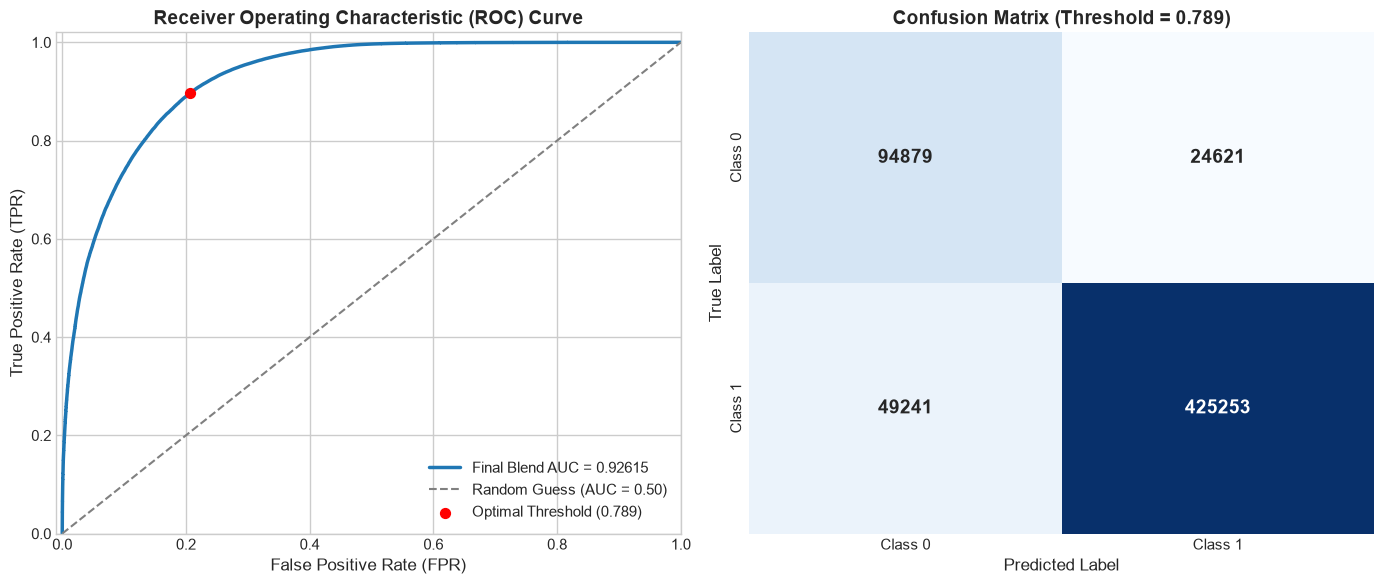

✅ Saved complete deployment pipeline successfully to 'deploy_pipeline.pkl'!


In [64]:
# ==========================================
# 5. THRESHOLD OPTIMIZATION & DEPLOYMENT ARTIFACTS
# ==========================================

auc_score = roc_auc_score(y, oof_final)
fpr, tpr, thresholds = roc_curve(y, oof_final)
optimal_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[optimal_idx]

y_pred_binary = (oof_final >= best_threshold).astype(int)
cm = confusion_matrix(y, y_pred_binary)

# Diagnostic Plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Final Blend AUC = {auc_score:.5f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess (AUC = 0.50)')
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=50, zorder=5, label=f'Optimal Threshold ({best_threshold:.3f})')
axes[0].set_xlim([-0.01, 1.0])
axes[0].set_ylim([0.0, 1.02])
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1], annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title(f'Confusion Matrix (Threshold = {best_threshold:.3f})', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Class 0', 'Class 1'], fontsize=11)
axes[1].set_yticklabels(['Class 0', 'Class 1'], fontsize=11)

plt.tight_layout()
plt.show()

# Export Pickle Artifacts
deploy_artifacts = {
    'skewed_cols': skewed_cols,
    'numerical_features': numerical_features,
    'iqr_bounds': iqr_bounds,
    'target_maps': global_target_maps,
    'freq_maps': freq_maps,
    'bin_edges': bin_edges_dict,
    'ohe': ohe,
    'onehot_cols': onehot_cols,
    'lgb_models': lgb_models,
    'xgb_models': xgb_models,
    'cat_models': cat_models,
    'weights': [w_lgb, w_xgb, w_cat],
    'best_threshold': best_threshold,
    'feature_names': X.columns.tolist()
}

with open('deploy_pipeline.pkl', 'wb') as f:
    pickle.dump(deploy_artifacts, f)

print("✅ Saved complete deployment pipeline successfully to 'deploy_pipeline.pkl'!")

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy = accuracy_score(y, y_pred_binary)
precision = precision_score(y, y_pred_binary)
recall = recall_score(y, y_pred_binary)
f1 = f1_score(y, y_pred_binary)

print("\n" + "=" * 50)
print("📊 FINAL MODEL METRICS")
print("=" * 50)

print(f"ROC-AUC   : {auc_score:.5f}")
print(f"Threshold : {best_threshold:.5f}")
print(f"Accuracy  : {accuracy:.5f}")
print(f"Precision : {precision:.5f}")
print(f"Recall    : {recall:.5f}")
print(f"F1 Score  : {f1:.5f}")

print("\nConfusion Matrix:")
print(cm)

print("=" * 50)


📊 FINAL MODEL METRICS
ROC-AUC   : 0.92615
Threshold : 0.78908
Accuracy  : 0.87565
Precision : 0.94527
Recall    : 0.89622
F1 Score  : 0.92009

Confusion Matrix:
[[ 94879  24621]
 [ 49241 425253]]
